In [8]:
tagger.tagger.setConditionalFilter(trigger=[1], filtered=[6])

In [11]:
# ## 1. Imports
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from collections import namedtuple
import time
from tqdm.auto import tqdm # Import tqdm for progress bars
from toptica.lasersdk.dlcpro.v2_0_3 import DLCpro, NetworkConnection
def do_ple_scan(lines = 1, in_range = None, frequency=None, resolution=None, channel = None):
    """
    fine_scan_range = (
            ple_gui.fit_result[1].best_values['center']
            - ple_gui.fit_result[1].best_values['sigma'] * 3,
            ple_gui.fit_result[1].best_values['center']
            + ple_gui.fit_result[1].best_values['sigma']  * 3
        )
    """
    if channel is not None:
        ple_gui._mw.channel_comboBox.setCurrentText(channel) ## MAY BE MISTAKEN
        # ple_gui._mw.channel_comboBox.setCurrentText('APD4')
    #laser_scanner_logic.scan_ranges["a"]
    if in_range is None:
        ple_gui._mw.actionFull_range.triggered.emit()
    else:
        ple_gui.sigScanSettingsChanged.emit(
            {'range': {ple_gui.scan_axis: in_range}}
        )
    ple_gui._mw.number_of_repeats_SpinBox.setValue(lines)
    ple_gui._mw.number_of_repeats_SpinBox.editingFinished.emit()
    time.sleep(0.5)
    ple_gui._mw.actionToggle_scan.setChecked(True)
    ple_gui.toggle_scan()
    while laser_scanner_logic.module_state()=='locked':
            time.sleep(0.5)
    time.sleep(0.2)
    ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("TwoLorentz")
    time.sleep(0.2)
    #ple_gui._accumulated_data.mean(axis=0)
    #print(f"Rsquared {ple_gui.fit_result[1].rsquared}")
    #ple_gui.fit_result[1].params["center"].value
    return ple_gui.fit_result[1]

def save_ple(tag, poi_name=None, folder_name = None):
        if folder_name:
            ple_gui._save_folderpath = folder_name
            ple_gui.save_path_widget.currPathLabel.setText(ple_gui._save_folderpath)
        ple_gui.save_path_widget.saveTagLineEdit.setText(
            f"{tag}"
            )
        ple_gui._mw.actionSave.triggered.emit()
def go_to_ple_target(target):
    ple_gui._mw.ple_widget.target_point.setValue(target)
    ple_gui._mw.ple_widget.target_point.sigPositionChangeFinished.emit(target)
    #laser_scanner_logic.set_target_position({"a": target})
    time.sleep(0.5)

In [ ]:
# time.sleep(2)
ple_gui._fit_averaged = False
dlc.laser1.wide_scan.continuous_mode.set(False)

with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        while laser_scanner_logic.module_state()=='locked':
                time.sleep(1)
                laser_state = dlc._laser1.wide_scan.state.get()
                if laser_state == 0:
                        ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("Lorentzian")
                        time.sleep(0.2)
                        fit = ple_gui.fit_result[1]
                        if fit.rsquared < 0.5:
                                switch_combiner_interfuse.set_state(switch="GreenBF", state="On")
                                switch_combiner_interfuse.set_state(switch="ResonantBF", state="Off")
                                time.sleep(2)
                                switch_combiner_interfuse.set_state(switch="GreenBF", state="Off")
                                switch_combiner_interfuse.set_state(switch="ResonantBF", state="On")
                        
                        dlc._laser1.wide_scan.start()
tag = f"long_ple_stability_measeurement"
save_ple(tag=tag, poi_name=None, folder_name=output_folder)

In [26]:
ple_gui._mw.number_of_repeats_SpinBox.setValue(
            10
        )
ple_gui._mw.number_of_repeats_SpinBox.editingFinished.emit()

True

In [32]:
data =np.array(laser_scanner_logic.scan_data.data[laser_scanner_logic._channel])

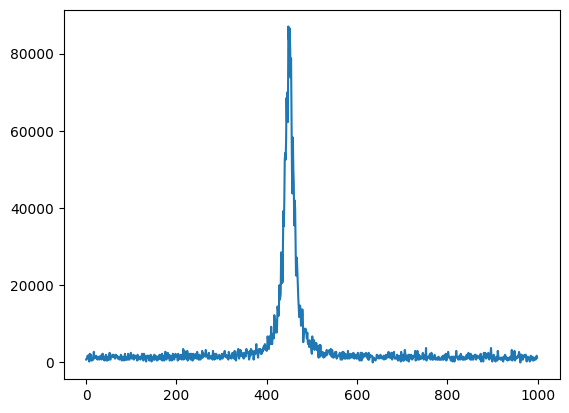

In [33]:
plt.plot(data)

In [34]:
import numpy as np
from scipy.signal import find_peaks
def pick_brightest_peak(
    y: np.ndarray,
    max_peaks: int = 6,
    prominence: float = 0.05,  # relative to max(y) if < 1
    distance: int | None = None,  # min samples between peaks
    width: int | None = None,     # min width in samples
    smooth_sigma: float | None = None,  # e.g. 1–3 to tame noise (requires SciPy)
):
    """
    Find up to `max_peaks` peaks and return the brightest one.
    Returns dict with keys: peaks_all, heights_all, peaks_top, heights_top, brightest_idx, brightest_height.
    """
    y = np.asarray(y).astype(float)
    if y.ndim != 1:
        raise ValueError("y must be a 1D array")

    ymax = np.nanmax(y)
    if ymax <= 0 or not np.isfinite(ymax):
        return {"peaks_all": np.array([], int), "heights_all": np.array([]),
                "peaks_top": np.array([], int), "heights_top": np.array([]),
                "brightest_idx": None, "brightest_height": None}

    # Optional smoothing (nice for noisy traces)
    y_proc = y.copy()
    if smooth_sigma is not None:
        try:
            from scipy.ndimage import gaussian_filter1d
            y_proc = gaussian_filter1d(y_proc, sigma=smooth_sigma, mode="nearest")
        except Exception:
            pass  # no smoothing if SciPy missing

    # Try SciPy peak finder first
    try:
        

        prom_abs = prominence * ymax if 0 < prominence < 1 else prominence
        peaks, props = find_peaks(y_proc, prominence=prom_abs, distance=distance, width=width)
        heights = y[peaks]  # use original (unsmoothed) heights
    except Exception:
        # Fallback: local-maximum test with a fixed neighborhood (very simple)
        if distance is None:
            distance = 5
        peaks = []
        for i in range(distance, len(y_proc) - distance):
            seg = y_proc[i - distance:i + distance + 1]
            if np.argmax(seg) == distance:  # center is max
                if y_proc[i] >= (prominence * ymax if 0 < prominence < 1 else prominence):
                    peaks.append(i)
        peaks = np.array(peaks, dtype=int)
        heights = y[peaks]

    if peaks.size == 0:
        return {"peaks_all": peaks, "heights_all": heights,
                "peaks_top": peaks, "heights_top": heights,
                "brightest_idx": None, "brightest_height": None}

    # Keep up to N brightest
    order = np.argsort(heights)[::-1]
    top_order = order[:max_peaks]
    peaks_top = peaks[top_order]
    heights_top = heights[top_order]

    brightest_idx = peaks_top[0]
    brightest_height = heights_top[0]

    return {
        "peaks_all": peaks,          # all detected
        "heights_all": heights,
        "peaks_top": peaks_top,      # up to `max_peaks` brightest
        "heights_top": heights_top,
        "brightest_idx": int(brightest_idx),
        "brightest_height": float(brightest_height),
    }


In [37]:
peaks = pick_brightest_peak(data, distance=20, prominence=0.1, width=5, smooth_sigma=2)

In [39]:
data[peaks["brightest_idx"]]

83250.0

In [44]:
fit = ple_gui.fit_result[1]

In [45]:
fit.rsquared

0.7641405883468602

In [27]:
field_targets

NameError: name 'field_targets' is not defined

In [2]:
import time

In [1]:
for i in range(50):
    # Start scan and save data
    scanning_probe_logic.toggle_scan(True, ('x', 'y'))
    while scanning_probe_logic.module_state()=='locked':
            time.sleep(1)
    

NameError: name 'time' is not defined

In [22]:
vector_magnet.ramp(field_target= [-0.11, 0.277, -0.0])

In [1]:
vector_magnet.ramp(field_target= [0.0, 0.0, 0.0])

In [29]:
initial_vector = [-0.11, 0.277, -0.0]
steps = 5
v_initial = np.array(initial_vector, dtype=float)

scaling_factors = np.linspace(0.50, 2.5, num=steps)

for i, factor in enumerate(scaling_factors):
    # Calculate the scaled vector
    v_scaled = factor * v_initial

    # Calculate the original magnitude (length) for comparison
    original_magnitude = np.linalg.norm(v_initial)
    # Calculate the current magnitude
    current_magnitude = np.linalg.norm(v_scaled)

    print(f"Step {i+1} | Scaling Factor: {factor:.3f}")
    print(f"  Scaled Vector: [{v_scaled[0]:.4f}, {v_scaled[1]:.4f}, {v_scaled[2]:.4f}]")
    print(f"  Current Length: {current_magnitude:.4f} (Original Length: {original_magnitude:.4f})")
    


Step 1 | Scaling Factor: 0.500
  Scaled Vector: [-0.0550, 0.1385, -0.0000]
  Current Length: 0.1490 (Original Length: 0.2980)
Step 2 | Scaling Factor: 1.000
  Scaled Vector: [-0.1100, 0.2770, -0.0000]
  Current Length: 0.2980 (Original Length: 0.2980)
Step 3 | Scaling Factor: 1.500
  Scaled Vector: [-0.1650, 0.4155, -0.0000]
  Current Length: 0.4471 (Original Length: 0.2980)
Step 4 | Scaling Factor: 2.000
  Scaled Vector: [-0.2200, 0.5540, -0.0000]
  Current Length: 0.5961 (Original Length: 0.2980)
Step 5 | Scaling Factor: 2.500
  Scaled Vector: [-0.2750, 0.6925, -0.0000]
  Current Length: 0.7451 (Original Length: 0.2980)


In [8]:
0.650 / (9.05-7.92)

0.5752212389380528

In [9]:
0.5752212389380528 * 700

402.6548672566369

In [2]:
ple_gui._fit_averaged = False

In [27]:
from TimeTagger import createTimeTagger,createTimeTaggerNetwork,AccessMode, Dump, GatedChannelInitial, Correlation, Histogram, Counter, CountBetweenMarkers, FileWriter, Countrate, Combiner, TimeDifferences, GatedChannel, DelayedChannel, freeTimeTagger

In [28]:
tagger.tagger = createTimeTaggerNetwork(f'{tagger._remote_tagger_ip}:{tagger._remote_tagger_port}')

TypeError: cannot pickle 'SwigPyObject' object

========= Remote Traceback (2) =========
Traceback (most recent call last):
  File "C:\Users\YY3\anaconda3\envs\squdi\lib\site-packages\rpyc\core\protocol.py", line 369, in _dispatch_request
    res = self._HANDLERS[handler](self, *args)
  File "C:\Users\YY3\anaconda3\envs\squdi\lib\site-packages\rpyc\core\protocol.py", line 885, in _handle_setattr
    return self._access_attr(obj, name, (value,), "_rpyc_setattr", "allow_setattr", setattr)
  File "C:\Users\YY3\anaconda3\envs\squdi\lib\site-packages\rpyc\core\protocol.py", line 807, in _access_attr
    return accessor(obj, name, *args)
  File "C:\Users\YY3\GIT\squdi-core\src\qudi\core\services.py", line 275, in __setattr__
    return setattr(obj, name, netobtain(value))
  File "C:\Users\YY3\GIT\squdi-core\src\qudi\util\network.py", line 32, in netobtain
    return _classic.obtain(obj)
  File "C:\Users\YY3\anaconda3\envs\squdi\lib\site-packages\rpyc\utils\classic.py", line 296, in obtain
  

In [48]:
vector_magnet.ramp(field_target= [0.0,0.0,0.087])

In [49]:
vector_magnet.ramp(field_target= [0.0,0.0,0.0])

In [ ]:

fit = do_ple_scan(lines=2, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')

In [17]:
time.sleep(0.2)
ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("TwoLorentz")
time.sleep(0.2)

In [9]:
ple_gui.fit_result[1].params["center_1"].value

10111.510460510637

In [25]:
go_to_ple_target(ple_gui.fit_result[1].params["center_1"].value)

In [21]:
poi_manager_logic._optimizelogic().set_optimize_settings(
                           {
                        'scan_frequency': {'z': 50, 'x': 50, 'y': 50},
                        'data_channel': 'APD2',
                        'scan_sequence' : ('xy', 'z'),
                        'scan_range': {'z': 2.2e-06, 'x': 2e-06, 'y': 2e-06},
                        'scan_resolution': {'z': 200, 'x': 25, 'y': 25},
                    }
                            )

{'scan_frequency': {'z': 50, 'x': 50, 'y': 50}, 'data_channel': 'APD2', 'scan_range': {'z': 2.2e-06, 'x': 2e-06, 'y': 2e-06}, 'scan_resolution': {'z': 200, 'x': 25, 'y': 25}, 'scan_sequence': [('x', 'y'), ('z',)]}

0

In [28]:
poi_manager_logic._optimizelogic()._optimize_spline_options['to_spline_1d'] = True
poi_manager_logic._optimizelogic()._optimize_spline_options['to_spline_2d'] = False

poi_manager_logic._optimizelogic()._optimize_spline_options['s_1d'] = 1.25


In [ ]:
poi_manager_logic._optimizelogic().start_optimize()

In [3]:
ple_gui._fit_averaged = False

In [37]:
vector_magnet.ramp(field_target= [0.0,0.0,0.05])

In [10]:
import os
import time
import numpy as np
from tqdm import tqdm

BASE_FOLDER = r'Z:\Vlad\heavyIV\202-2-ARed\CPW-IV\B_sweep_def7-230-II'
B_AMPLITUDE = 0.9  # Tesla
NUM_STEPS = 50     # Number of points per 90-degree arc
Bx_offset = 0

print("Generating B-field target points for all planes...")
angles = np.linspace(0, 2*np.pi, NUM_STEPS)

sweep_definitions = {
   
    'YZ': {
        'points': list(zip(
            np.zeros(NUM_STEPS) + Bx_offset,               # Bx
            B_AMPLITUDE * np.sin(angles),      # By
            B_AMPLITUDE * np.cos(angles)       # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_YZ_perp')
    },
    'XZ': {
        'points': list(zip(
            B_AMPLITUDE * np.sin(angles),      # Bx
            np.zeros(NUM_STEPS),               # By
            B_AMPLITUDE * np.cos(angles)       # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_XZ_perp')
    },
     'XY': {
        'points': list(zip(
            B_AMPLITUDE * np.cos(angles),      # Bx
            B_AMPLITUDE * np.sin(angles),      # By
            np.zeros(NUM_STEPS)                # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_XY_perp')
    },
}

# ==============================================================================
# ## 3. Main Measurement Function
# ==============================================================================
def run_planar_sweep(plane_name: str, field_targets: list, output_folder: str):
    """
    Executes a full B-field sweep measurement for a given set of points.
    
    Args:
        plane_name (str): Name of the plane being swept (e.g., 'XY').
        field_targets (list): A list of [Bx, By, Bz] target tuples.
        output_folder (str): The full path to the folder where data will be saved.
    """
    print(f"\n--- 🚀 Starting Measurement for Plane: {plane_name} ---")
    
    # --- Create and verify destination folder ---
    if os.path.exists(output_folder):
        raise FileExistsError(f"The folder '{output_folder}' already exists. Please rename or delete it.")
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")
    
    ple_splitting = []
    field_targets = np.array(field_targets)
    # --- Main Loop with Progress Bar ---
    for field_target in tqdm(field_targets, desc=f"{plane_name} Sweep Progress"):
        
        
        # 1. Ramp the field
        vector_magnet.ramp(field_target=field_target)
        while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
            time.sleep(2)
        

        # 2. Perform PLE Scan
        max_attempts = 5
        attempt = 0
        
       

        ple_gui._fit_averaged = True
        #switch_combiner_interfuse.set_state(switch="GreenBF", state="On")
        #switch_combiner_interfuse.set_state(switch="ResonantBF", state="On")
        #fit = do_ple_scan(lines=2, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
        #tag = f"CHARGE_CHECK_target_{field_target[0]:.4f}_{field_target[1]:.4f}_{field_target[2]:.4f}_T"
        #save_ple(tag=tag, poi_name=None, folder_name=output_folder)
        # ple_gui._fit_averaged = False
        # go_to_ple_target(fit.params['center_1'].value)
        #switch_combiner_interfuse.set_state(switch="GreenBF", state="Off")

        while attempt < max_attempts:
            
            # switch_combiner_interfuse.set_state(switch="ResonantBF", state="On")
            fit = do_ple_scan(lines=2, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
            if fit.rsquared >= 0.3:
                # 5. Save Data
                tag = f"target_{field_target[0]:.4f}_{field_target[1]:.4f}_{field_target[2]:.4f}_T"
                save_ple(tag=tag, poi_name=None, folder_name=output_folder)
                break
            else:
                switch_combiner_interfuse.set_state(switch="GreenBF", state="On")
                switch_combiner_interfuse.set_state(switch="ResonantBF", state="Off")
                time.sleep(0.5)
                switch_combiner_interfuse.set_state(switch="GreenBF", state="Off")
                switch_combiner_interfuse.set_state(switch="ResonantBF", state="On")
            attempt += 1
        
        # 3. Wait for Laser Scanner to be ready
        while laser_scanner_logic.module_state() == 'locked':
            time.sleep(0.5)
        

        # 4. Calculate Splitting
        delta = fit.params['center_2'].value - fit.params['center_1'].value
        ple_splitting.append(delta)
        

        # 5. Save Data
        tag = f"target_{field_target[0]:.4f}_{field_target[1]:.4f}_{field_target[2]:.4f}_T"
        save_ple(tag=tag, poi_name=None, folder_name=output_folder)
        
    print(f"\n✅ --- {plane_name} Measurement Complete! ---")
    return ple_splitting


Generating B-field target points for all planes...


In [20]:

BASE_FOLDER = r'Z:\Vlad\heavyIV\202-2-ARed\CPW-IV\B_sweep_def7-230-II'
B_AMPLITUDE = 0.9  # Tesla
NUM_STEPS = 20     # Number of points
Bx_offset = 0

# Parameters for the small-angle arc sweep
# This defines a 30-degree sweep (+/- 15 degrees) around the Y-axis in the YZ plane.
ARC_SPAN_DEGREES = 30.0 

print("Generating B-field target points for all sweep types...")

# --- Define angles for the full circle sweeps ---
full_circle_angles = np.linspace(0, 2 * np.pi, NUM_STEPS)

# --- Define angles for the YZ arc sweep ---
# The Y-axis in the YZ plane is at 90 degrees (pi/2 radians).
center_angle_rad = np.pi / 2
span_rad = np.deg2rad(ARC_SPAN_DEGREES)
start_angle = center_angle_rad - (span_rad / 2)
end_angle = center_angle_rad + (span_rad / 2)
arc_angles = np.linspace(start_angle, end_angle, NUM_STEPS)


sweep_definitions = {
    'XY': {
        'points': list(zip(
            B_AMPLITUDE * np.cos(full_circle_angles),      # Bx
            B_AMPLITUDE * np.sin(full_circle_angles),      # By
            np.zeros(NUM_STEPS)                            # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_XY_perp')
    },
    'XZ': {
        'points': list(zip(
            B_AMPLITUDE * np.sin(full_circle_angles),      # Bx
            np.zeros(NUM_STEPS),                           # By
            B_AMPLITUDE * np.cos(full_circle_angles)       # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_XZ_perp')
    },
    'YZ': {
        'points': list(zip(
            np.zeros(NUM_STEPS) + Bx_offset,               # Bx
            B_AMPLITUDE * np.sin(full_circle_angles),      # By
            B_AMPLITUDE * np.cos(full_circle_angles)       # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_YZ_perp')
    },
    # Definition for the small-angle YZ sweep ---
    'YZ_arc': {
        'points': list(zip(
            np.zeros(NUM_STEPS) + Bx_offset,               # Bx
            B_AMPLITUDE * np.sin(arc_angles),              # By (will be strong)
            B_AMPLITUDE * np.cos(arc_angles)               # Bz (will be small)
        )),
        'folder': os.path.join(BASE_FOLDER, f'B_sweep_YZ_arc_{ARC_SPAN_DEGREES}deg')
    },
}

Generating B-field target points for all sweep types...


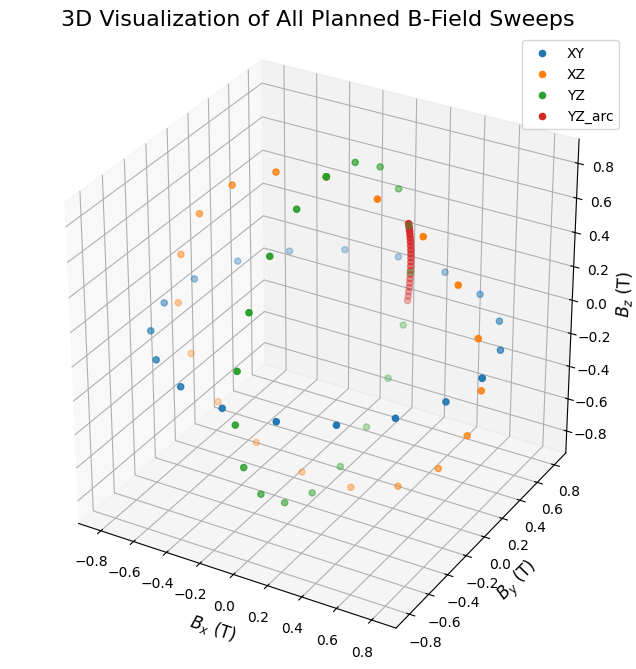

In [21]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the points for each plane
for plane_name, config in sweep_definitions.items():
    # Unzip the list of (x, y, z) tuples into three separate lists

    points = config['points']
    if not points: continue # Skip if no points
    x_coords, y_coords, z_coords = zip(*points)
    
    # Create the scatter plot for the current plane
    ax.scatter(x_coords, y_coords, z_coords,  marker='o', label=plane_name)

# --- Add labels and titles for clarity ---
ax.set_xlabel('$B_x$ (T)', fontsize=12)
ax.set_ylabel('$B_y$ (T)', fontsize=12)
ax.set_zlabel('$B_z$ (T)', fontsize=12)
ax.set_title('3D Visualization of All Planned B-Field Sweeps', fontsize=16)

# --- Set axis limits and aspect ratio ---
ax.set_xlim([-B_AMPLITUDE, B_AMPLITUDE])
ax.set_ylim([-B_AMPLITUDE, B_AMPLITUDE])
ax.set_zlim([-B_AMPLITUDE, B_AMPLITUDE])
ax.set_aspect('equal')  # Crucial for correct spherical appearance

# --- Add legend and grid ---
ax.legend()
ax.grid(True)


In [9]:
output_folder = r'Z:\Vlad\heavyIV\202-2-ARed\CPW-IV\B_sweep_def1-234-II'
tag = f"long_ple_stability_measeurement"
save_ple(tag=tag, poi_name=None, folder_name=output_folder)

In [11]:
ple_gui._mw.actionToggle_scan.setChecked(False)
ple_gui.toggle_scan()

In [16]:
sweep_definitions_ = {i:j for i, j in sweep_definitions.items() if i != 'XY'}

In [17]:
sweep_definitions_

{'YZ': {'points': [(0.0, 0.0, 0.3), (0.0, 0.025441777342652756, 0.2989192465627579), (0.0, 0.05070024609655472, 0.2956847731043125), (0.0, 0.07559341841553756, 0.29031988408004966), (0.0, 0.09994193842261727, 0.2828632336383253), (0.0, 0.12357037447319777, 0.2733685471164407), (0.0, 0.14630848314409037, 0.26190423394835644), (0.0, 0.1679924358412786, 0.24855289477315265), (0.0, 0.18846599918869267, 0.23341072629553183), (0.0, 0.2075816606932638, 0.21658682818635736), (0.0, 0.2252016915758173, 0.19820241701702443), (0.0, 0.24119913911008214, 0.178389952891286), (0.0, 0.25545874131999335, 0.1572921850671695), (0.0, 0.2678777574448705, 0.13506112344530197), (0.0, 0.2783667081889528, 0.11185694333409259), (0.0, 0.28685002042177526, 0.08784683138296513), (0.0, 0.2932665716843058, 0.06320378099871793), (0.0, 0.297570130577663, 0.03810534592406366), (0.0, 0.2997296898614044, 0.012732360958844538), (0.0, 0.29972968986140447, -0.012732360958844434), (0.0, 0.2975701305776631, -0.0381053459240635

In [ ]:
# ple_gui._mw.actionToggle_scan.setChecked(True)
# ple_gui.toggle_scan()
# time.sleep(2)
# with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
#         dlc.laser1.wide_scan.continuous_mode.set(False)
#         while laser_scanner_logic.module_state()=='locked':
                
#                 time.sleep(1)
#                 laser_state = dlc._laser1.wide_scan.state.get()
#                 if laser_state == 0:
#                         ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("Lorentzian")
#                         time.sleep(0.2)
#                         fit = ple_gui.fit_result[1]
#                         if fit.rsquared < 0.5:
#                                 switch_combiner_interfuse.set_state(switch="GreenBF", state="On")
#                                 switch_combiner_interfuse.set_state(switch="ResonantBF", state="Off")
#                                 time.sleep(2)
#                                 switch_combiner_interfuse.set_state(switch="GreenBF", state="Off")
#                                 switch_combiner_interfuse.set_state(switch="ResonantBF", state="On")
                        
#                         dlc._laser1.wide_scan.start()
# tag = f"long_ple_stability_measeurement"
# save_ple(tag=tag, poi_name=None, folder_name=output_folder)
                        
# ==============================================================================
# ## 4. Execute All Measurements
# ==============================================================================
all_results = {}
sweep_definitions_ = {i:j for i, j in sweep_definitions.items() if i == 'YZ_arc' } #
try:
    # --- Initial Magnet Check ---
    print("Waiting for initial vector magnet state...")
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
        time.sleep(30)
    print("✅ Vector magnet is ready to begin the measurement sequence.")

    # --- Loop through and run each defined sweep ---
    for plane, config in sweep_definitions_.items():
       
        results = run_planar_sweep(
            plane_name=plane,
            field_targets=config['points'],
            output_folder=config['folder']
        )
        all_results[plane] = results

except (Exception, KeyboardInterrupt) as e:
    print(f"\n\n❌ An error occurred or the script was interrupted: {e}")
    print("Measurement sequence aborted.")

finally:
    # --- Final Summary ---
    print("\n\n" + "="*50)
    print("--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---")
    print("="*50)
    vector_magnet.ramp(field_target= [0.0,0.0,0.0])
    if not all_results:
        print("No measurements were completed.")
    else:
        for plane, splits in all_results.items():
            print(f"\nResults for {plane} Plane:")
            # print(f"  - Data saved in: {sweep_definitions[plane]['folder']}")
            # print(f"  - Final PLE Splitting Values (MHz): {np.round(splits, 2).tolist()}")
    print("\n--- Script finished. ---")

Waiting for initial vector magnet state...
✅ Vector magnet is ready to begin the measurement sequence.

--- 🚀 Starting Measurement for Plane: YZ ---
Created folder: Z:\Vlad\heavyIV\202-2-ARed\CPW-IV\B_sweep_def7-230\B_sweep_YZ_perp


YZ Sweep Progress:  14%|█▍        | 7/50 [41:51<2:50:55, 238.50s/it]  

: 

NameError: name 'output_folder' is not defined

In [35]:
# ple_gui._mw.actionToggle_scan.setChecked(True)
# ple_gui.toggle_scan()
# time.sleep(2)
# with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
#         dlc.laser1.wide_scan.continuous_mode.set(False)
#         while laser_scanner_logic.module_state()=='locked':
                
#                 time.sleep(1)
#                 laser_state = dlc._laser1.wide_scan.state.get()
#                 if laser_state == 0:
#                         ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("Lorentzian")
#                         time.sleep(0.2)
#                         fit = ple_gui.fit_result[1]
#                         if fit.rsquared < 0.5:
#                                 switch_combiner_interfuse.set_state(switch="GreenBF", state="On")
#                                 switch_combiner_interfuse.set_state(switch="ResonantBF", state="Off")
#                                 time.sleep(2)
#                                 switch_combiner_interfuse.set_state(switch="GreenBF", state="Off")
#                                 switch_combiner_interfuse.set_state(switch="ResonantBF", state="On")
                        
#                         dlc._laser1.wide_scan.start()
# tag = f"long_ple_stability_measeurement"
# save_ple(tag=tag, poi_name=None, folder_name=output_folder)
                        
# ==============================================================================
# ## 4. Execute All Measurements
# ==============================================================================
all_results = {}
sweep_definitions_ = {i:j for i, j in sweep_definitions.items() if i != 'YZ' } #
try:
    # --- Initial Magnet Check ---
    print("Waiting for initial vector magnet state...")
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
        time.sleep(30)
    print("✅ Vector magnet is ready to begin the measurement sequence.")

    # --- Loop through and run each defined sweep ---
    for plane, config in sweep_definitions_.items():
       
        results = run_planar_sweep(
            plane_name=plane,
            field_targets=config['points'],
            output_folder=config['folder']
        )
        all_results[plane] = results

except (Exception, KeyboardInterrupt) as e:
    print(f"\n\n❌ An error occurred or the script was interrupted: {e}")
    print("Measurement sequence aborted.")

finally:
    # --- Final Summary ---
    print("\n\n" + "="*50)
    print("--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---")
    print("="*50)
    vector_magnet.ramp(field_target= [0.0,0.0,0.0])
    if not all_results:
        print("No measurements were completed.")
    else:
        for plane, splits in all_results.items():
            print(f"\nResults for {plane} Plane:")
            # print(f"  - Data saved in: {sweep_definitions[plane]['folder']}")
            # print(f"  - Final PLE Splitting Values (MHz): {np.round(splits, 2).tolist()}")
    print("\n--- Script finished. ---")

Waiting for initial vector magnet state...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Waiting...
Current ramping state: [2, 2, 1] - Wa

XZ Sweep Progress: 100%|██████████| 50/50 [3:10:05<00:00, 228.11s/it]  



✅ --- XZ Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: XY ---
Created folder: Z:\Vlad\heavyIV\202-2-ARed\CPW-IV\B_sweep_def4-245-2\B_sweep_XY_perp


XY Sweep Progress:  86%|████████▌ | 43/50 [2:51:09<24:17, 208.23s/it]  

: 

In [23]:
vector_magnet.ramp(field_target= [0,0.,0.0])

In [2]:
ni_tt_finite_sampling_input.pulsed = False
ni_tt_finite_sampling_input.use_ref = False

In [ ]:
0.0096_0.2998_0.0000

In [38]:
vector_magnet.ramp(field_target= [0.,0.,0.0])

In [ ]:

# ==============================================================================
# ## 4. Execute All Measurements
# ==============================================================================
all_results = {}

try:
    # --- Initial Magnet Check ---
    print("Waiting for initial vector magnet state...")
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
        time.sleep(30)
    print("✅ Vector magnet is ready to begin the measurement sequence.")

    # --- Loop through and run each defined sweep ---
    for plane, config in sweep_definitions.items():
       
        results = run_planar_sweep(
            plane_name=plane,
            field_targets=config['points'],
            output_folder=config['folder']
        )
        all_results[plane] = results

except (Exception, KeyboardInterrupt) as e:
    print(f"\n\n❌ An error occurred or the script was interrupted: {e}")
    print("Measurement sequence aborted.")

finally:
    # --- Final Summary ---
    print("\n\n" + "="*50)
    print("--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---")
    print("="*50)
    vector_magnet.ramp(field_target= [0.0,0.0,0.0])
    if not all_results:
        print("No measurements were completed.")
    else:
        for plane, splits in all_results.items():
            print(f"\nResults for {plane} Plane:")
            # print(f"  - Data saved in: {sweep_definitions[plane]['folder']}")
            # print(f"  - Final PLE Splitting Values (MHz): {np.round(splits, 2).tolist()}")
    print("\n--- Script finished. ---")

Waiting for initial vector magnet state...
✅ Vector magnet is ready to begin the measurement sequence.

--- 🚀 Starting Measurement for Plane: YZ ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_YZ_perp


YZ Sweep Progress: 100%|██████████| 20/20 [1:02:11<00:00, 186.58s/it]



✅ --- YZ Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: XZ ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_XZ_perp


XZ Sweep Progress: 100%|██████████| 20/20 [56:12<00:00, 168.62s/it]



✅ --- XZ Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: XY ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_XY_perp


XY Sweep Progress: 100%|██████████| 20/20 [1:01:21<00:00, 184.06s/it]


✅ --- XY Measurement Complete! ---


--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---

Results for YZ Plane:

Results for XZ Plane:

Results for XY Plane:

--- Script finished. ---


In [ ]:

# ==============================================================================
# ## 4. Execute All Measurements
# ==============================================================================
all_results = {}

try:
    # --- Initial Magnet Check ---
    print("Waiting for initial vector magnet state...")
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
        time.sleep(30)
    print("✅ Vector magnet is ready to begin the measurement sequence.")

    # --- Loop through and run each defined sweep ---
    for plane, config in sweep_definitions.items():
       
        results = run_planar_sweep(
            plane_name=plane,
            field_targets=config['points'],
            output_folder=config['folder']
        )
        all_results[plane] = results

except (Exception, KeyboardInterrupt) as e:
    print(f"\n\n❌ An error occurred or the script was interrupted: {e}")
    print("Measurement sequence aborted.")

finally:
    # --- Final Summary ---
    print("\n\n" + "="*50)
    print("--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---")
    print("="*50)
    vector_magnet.ramp(field_target= [0.0,0.0,0.0])
    if not all_results:
        print("No measurements were completed.")
    else:
        for plane, splits in all_results.items():
            print(f"\nResults for {plane} Plane:")
            # print(f"  - Data saved in: {sweep_definitions[plane]['folder']}")
            # print(f"  - Final PLE Splitting Values (MHz): {np.round(splits, 2).tolist()}")
    print("\n--- Script finished. ---")

Waiting for initial vector magnet state...
✅ Vector magnet is ready to begin the measurement sequence.

--- 🚀 Starting Measurement for Plane: YZ ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_YZ_perp


YZ Sweep Progress: 100%|██████████| 20/20 [1:02:11<00:00, 186.58s/it]



✅ --- YZ Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: XZ ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_XZ_perp


XZ Sweep Progress: 100%|██████████| 20/20 [56:12<00:00, 168.62s/it]



✅ --- XZ Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: XY ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_XY_perp


XY Sweep Progress: 100%|██████████| 20/20 [1:01:21<00:00, 184.06s/it]


✅ --- XY Measurement Complete! ---


--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---

Results for YZ Plane:

Results for XZ Plane:

Results for XY Plane:

--- Script finished. ---


In [ ]:




# ==============================================================================
# ## 4. Execute All Measurements
# ==============================================================================
all_results = {}

try:
    # --- Initial Magnet Check ---
    print("Waiting for initial vector magnet state...")
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
        time.sleep(30)
    print("✅ Vector magnet is ready to begin the measurement sequence.")

    # --- Loop through and run each defined sweep ---
    for plane, config in sweep_definitions.items():
       
        results = run_planar_sweep(
            plane_name=plane,
            field_targets=config['points'],
            output_folder=config['folder']
        )
        all_results[plane] = results

except (Exception, KeyboardInterrupt) as e:
    print(f"\n\n❌ An error occurred or the script was interrupted: {e}")
    print("Measurement sequence aborted.")

finally:
    # --- Final Summary ---
    print("\n\n" + "="*50)
    print("--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---")
    print("="*50)
    vector_magnet.ramp(field_target= [0.0,0.0,0.0])
    if not all_results:
        print("No measurements were completed.")
    else:
        for plane, splits in all_results.items():
            print(f"\nResults for {plane} Plane:")
            # print(f"  - Data saved in: {sweep_definitions[plane]['folder']}")
            # print(f"  - Final PLE Splitting Values (MHz): {np.round(splits, 2).tolist()}")
    print("\n--- Script finished. ---")

Waiting for initial vector magnet state...
✅ Vector magnet is ready to begin the measurement sequence.

--- 🚀 Starting Measurement for Plane: YZ ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_YZ_perp


YZ Sweep Progress: 100%|██████████| 20/20 [1:02:11<00:00, 186.58s/it]



✅ --- YZ Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: XZ ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_XZ_perp


XZ Sweep Progress: 100%|██████████| 20/20 [56:12<00:00, 168.62s/it]



✅ --- XZ Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: XY ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_XY_perp


XY Sweep Progress: 100%|██████████| 20/20 [1:01:21<00:00, 184.06s/it]


✅ --- XY Measurement Complete! ---


--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---

Results for YZ Plane:

Results for XZ Plane:

Results for XY Plane:

--- Script finished. ---


In [ ]:

# ==============================================================================
# ## 4. Execute All Measurements
# ==============================================================================
all_results = {}

try:
    # --- Initial Magnet Check ---
    print("Waiting for initial vector magnet state...")
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
        time.sleep(30)
    print("✅ Vector magnet is ready to begin the measurement sequence.")

    # --- Loop through and run each defined sweep ---
    for plane, config in sweep_definitions.items():
       
        results = run_planar_sweep(
            plane_name=plane,
            field_targets=config['points'],
            output_folder=config['folder']
        )
        all_results[plane] = results

except (Exception, KeyboardInterrupt) as e:
    print(f"\n\n❌ An error occurred or the script was interrupted: {e}")
    print("Measurement sequence aborted.")

finally:
    # --- Final Summary ---
    print("\n\n" + "="*50)
    print("--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---")
    print("="*50)
    vector_magnet.ramp(field_target= [0.0,0.0,0.0])
    if not all_results:
        print("No measurements were completed.")
    else:
        for plane, splits in all_results.items():
            print(f"\nResults for {plane} Plane:")
            # print(f"  - Data saved in: {sweep_definitions[plane]['folder']}")
            # print(f"  - Final PLE Splitting Values (MHz): {np.round(splits, 2).tolist()}")
    print("\n--- Script finished. ---")

Waiting for initial vector magnet state...
✅ Vector magnet is ready to begin the measurement sequence.

--- 🚀 Starting Measurement for Plane: YZ ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_YZ_perp


YZ Sweep Progress: 100%|██████████| 20/20 [1:02:11<00:00, 186.58s/it]



✅ --- YZ Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: XZ ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_XZ_perp


XZ Sweep Progress: 100%|██████████| 20/20 [56:12<00:00, 168.62s/it]



✅ --- XZ Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: XY ---
Created folder: Z:\Vlad\heavyIV\158\170keV\mw-II-235\B0\B_sweep_XY_perp


XY Sweep Progress: 100%|██████████| 20/20 [1:01:21<00:00, 184.06s/it]


✅ --- XY Measurement Complete! ---


--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---

Results for YZ Plane:

Results for XZ Plane:

Results for XY Plane:

--- Script finished. ---


In [ ]:
import numpy as np

# Let's assume your function and inputs are the same
# (I've included the function here for a complete, runnable example)
def get_symmetry_vectors(angle_xy: float, angle_xz: float, angle_yz: float) -> tuple[np.ndarray, np.ndarray]:
    TOL = 1e-9
    if abs((angle_xz % 180) - 90) < TOL:
        vx = 0.0
        rad_yz = np.deg2rad(angle_yz)
        vy = np.cos(rad_yz)
        vz = np.sin(rad_yz)
        vector_aligned = np.array([vx, vy, vz])
    else:
        phi = np.deg2rad(angle_xy)
        rad_xz = np.deg2rad(angle_xz)
        cot_theta = np.tan(rad_xz) * np.cos(phi)
        sin_theta = 1.0 / np.sqrt(1 + cot_theta**2)
        cos_theta = cot_theta * sin_theta
        vx = sin_theta * np.cos(phi)
        vy = sin_theta * np.sin(phi)
        vz = cos_theta
        vector_aligned = np.array([vx, vy, vz])
    if abs(vector_aligned[0]) < 0.9:
        temp_vec = np.array([1.0, 0.0, 0.0])
    else:
        temp_vec = np.array([0.0, 1.0, 0.0])
    vector_perpendicular = np.cross(vector_aligned, temp_vec)
    vector_perpendicular /= np.linalg.norm(vector_perpendicular)
    return vector_aligned, vector_perpendicular

# --- Your original code ---
xy_proj_angle = -2.0
xz_proj_angle = 90.0
yz_proj_angle = 68.0

xy_proj_angle = -2
xz_proj_angle = 53
yz_proj_angle = 90.0 - 2

# Get the unit vector representing the direction
aligned_unit_vec, perp_unit_vec = get_symmetry_vectors(xy_proj_angle, xz_proj_angle, yz_proj_angle)

# --- NEW PART: Scaling the vector ---
# Define your desired B-field amplitude (e.g., 0.1 Tesla)
B_AMPLITUDE = 0.2 # Tesla

# Multiply the unit vector by the desired amplitude
b_field_vector = B_AMPLITUDE * aligned_unit_vec

print(f"Direction (Unit Vector): {np.round(aligned_unit_vec, 4)}")
print(f"B-Field Vector (0.1 T):  {np.round(b_field_vector, 4)}")

b_field_vector_perp = B_AMPLITUDE * perp_unit_vec
print(f"Direction (Unit Vector) Perp: {np.round(perp_unit_vec, 4)}")
print(f"B-Field Vector (0.1 T) Perp :  {np.round(b_field_vector_perp, 4)}")
# --- Verification ---
# You can verify the magnitude (norm) of the new vector
magnitude = np.linalg.norm(b_field_vector)
print(f"\nMagnitude of the final B-field vector: {magnitude:.4f} T")

Direction (Unit Vector): [ 0.6017 -0.021   0.7985]
B-Field Vector (0.1 T):  [ 0.1203 -0.0042  0.1597]
Direction (Unit Vector) Perp: [-0.      0.9997  0.0263]
B-Field Vector (0.1 T) Perp :  [-0.      0.1999  0.0053]

Magnitude of the final B-field vector: 0.2000 T


In [ ]:
aligned_unit_vec

array([ 0.60168217, -0.0210112 ,  0.7984592 ])

In [ ]:
vector_perpendicular

In [ ]:
vector_magnet.ramp(field_target= [0.,0.1,-0.02])

In [ ]:
vector_magnet.ramp(field_target= [0, 0.171, 0.104])

In [ ]:
vector_magnet

In [ ]:
vector_magnet.ramp(field_target= [0.0,0,0])

In [ ]:
ple_gui._fit_averaged = False

In [ ]:
import os
import time
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

# --- Assume these hardware control objects and functions are defined elsewhere ---
# from your_instrument_library import vector_magnet, laser_scanner_logic
# from your_analysis_library import do_ple_scan, save_ple

# ==============================================================================
# ## 1. Configuration
# ==============================================================================
# Define the base directory for saving all measurement data
BASE_FOLDER = r'Z:\Vlad\heavyIV\158\170keV\MW_6\B0'
B_AMPLITUDE = 0.2  # Tesla
NUM_STEPS = 100     # Number of points per sweep

# ==============================================================================
# ## 2. Define Defect Frame and Transformation
# ==============================================================================
print("Defining defect frame of reference...")

# ⬇️ ------------------ USER INPUT REQUIRED ------------------ ⬇️
# Define the defect's primary symmetry axis vector in the LAB FRAME.
# This vector must be measured or known beforehand.
# EXAMPLE: A defect axis pointing between X, Y, and Z.
DEFECT_AXIS = aligned_unit_vec #np.array([-0.0, .1124, 0.2782])  # Example vector in Tesla
# ⬆️ --------------------------------------------------------- ⬆️

# --- Normalize the defect axis to be a unit vector (our new z') ---
z_prime = DEFECT_AXIS / np.linalg.norm(DEFECT_AXIS)
print(f"Normalized Defect Axis (z'): {np.round(z_prime, 3)}")

# --- Create the other two orthogonal basis vectors (x' and y') ---
# This creates a full right-handed coordinate system (x', y', z').
# We use the Gram-Schmidt process, which is what Rotation.from_rotvec does internally.
# Find the rotation that maps the lab z-axis (0,0,1) to our defect z' axis.
align_rotation = Rotation.align_vectors(a=z_prime, b=[[0, 0, 1]])[0]

# Use this rotation to find where the lab x and y axes end up.
x_prime = align_rotation.apply([1, 0, 0])
y_prime = align_rotation.apply([0, 1, 0])

# The rotation matrix `R` transforms vectors from the DEFECT frame to the LAB frame.
# Its columns are the new basis vectors (x', y', z') expressed in lab coordinates.
R = np.column_stack([x_prime, y_prime, z_prime])
print("Rotation matrix from Defect Frame -> Lab Frame created.")


# ==============================================================================
# ## 3. Generate B-Field Target Points in the Defect Frame
# ==============================================================================
print("Generating B-field target points in the defect's frame...")
angles = np.linspace(0, 2 * np.pi, NUM_STEPS, endpoint=False)

# Define sweep points IN THE DEFECT'S COORDINATE SYSTEM (B_x', B_y', B_z')
# These are simple circles in the principal planes of the defect.
points_in_defect_frame = {
    # Sweep in the plane PERPENDICULAR to the defect axis (the x'-y' plane)
    'Perp_Plane': np.array([
        B_AMPLITUDE * np.cos(angles),  # B_x'
        B_AMPLITUDE * np.sin(angles),  # B_y'
        np.zeros(NUM_STEPS)            # B_z'
    ]).T,

    # Sweep in a plane CONTAINING the defect axis (the x'-z' plane)
    'Tilted_Plane_1': np.array([
        B_AMPLITUDE * np.cos(angles),  # B_x'
        np.zeros(NUM_STEPS),           # B_y'
        B_AMPLITUDE * np.sin(angles)   # B_z'
    ]).T,

    # Sweep in the other plane CONTAINING the defect axis (the y'-z' plane)
    'Tilted_Plane_2': np.array([
        np.zeros(NUM_STEPS),           # B_x'
        B_AMPLITUDE * np.cos(angles),  # B_y'
        B_AMPLITUDE * np.sin(angles)   # B_z'
    ]).T,
}

# --- Transform points to the Lab Frame and set up sweep definitions ---
sweep_definitions = {}
for plane_name, points_prime in points_in_defect_frame.items():
    # Use the rotation matrix R to convert all points to the lab frame
    # B_lab = R @ B_defect
    points_lab = (R @ points_prime.T).T

    sweep_definitions[plane_name] = {
        'points': list(map(tuple, points_lab)),
        'folder': os.path.join(BASE_FOLDER, f'B_sweep_{plane_name}')
    }

# ==============================================================================
# ## 4. Main Measurement Function (No changes needed here)
# ==============================================================================
def run_planar_sweep(plane_name: str, field_targets: list, output_folder: str):
    """
    Executes a full B-field sweep measurement for a given set of points.
    
    Args:
        plane_name (str): Name of the plane being swept (e.g., 'Perp_Plane').
        field_targets (list): A list of [Bx, By, Bz] target tuples in the LAB FRAME.
        output_folder (str): The full path to the folder where data will be saved.
    """
    print(f"\n--- 🚀 Starting Measurement for Plane: {plane_name} ---")
    
    # --- Create and verify destination folder ---
    if os.path.exists(output_folder):
        raise FileExistsError(f"The folder '{output_folder}' already exists. Please rename or delete it.")
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")

    ple_splitting = []
    field_targets = np.array(field_targets)
    # --- Main Loop with Progress Bar ---
    for field_target in tqdm(field_targets, desc=f"{plane_name} Sweep Progress"):
        # print(f"\n--- Ramping to target: ({field_target[0]:.3f}, {field_target[1]:.3f}, {field_target[2]:.3f}) T ---")
        
        # NOTE: This part is unchanged. It assumes the existence of the hardware control functions.
        # 1. Ramp the field
        vector_magnet.ramp(field_target=field_target)
        while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
            time.sleep(2)
        # print("Ramping complete.")
        max_attempts = 10
        attempt = 0
       
        while attempt < max_attempts:
            fit = do_ple_scan(lines=1, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
            if fit.rsquared >= 0.1:
                # 5. Save Data
                tag = f"CHARGE_CHECK_target_{field_target[0]:.4f}_{field_target[1]:.4f}_{field_target[2]:.4f}_T"
                save_ple(tag=tag, poi_name=None, folder_name=output_folder)
                break
            switch_combiner_interfuse.set_state(switch="GreenBF", state="On")
            switch_combiner_interfuse.set_state(switch="ResonantBF", state="Off")
            time.sleep(5)
            switch_combiner_interfuse.set_state(switch="GreenBF", state="Off")
            switch_combiner_interfuse.set_state(switch="ResonantBF", state="On")
            attempt += 1
        # 2. Perform PLE Scan
        # print("Performing PLE scan...")
        fit = do_ple_scan(lines=5, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
        
        # 3. Wait for Laser Scanner to be ready
        while laser_scanner_logic.module_state() == 'locked':
            time.sleep(0.5)
        # print("PLE scan complete.")

        # 4. Calculate Splitting
        delta = fit.params['center_2'].value - fit.params['center_1'].value
        ple_splitting.append(delta)
        # print(f"Calculated splitting: {delta:.2f} MHz")

        # 5. Save Data
        tag = f"target_{field_target[0]:.4f}_{field_target[1]:.4f}_{field_target[2]:.4f}_T"
        save_ple(tag=tag, poi_name=None, folder_name=output_folder)
        pass # Placeholder for the loop to run without hardware
        
    print(f"\n✅ --- {plane_name} Measurement Complete! ---")
    return ple_splitting
    
# ==============================================================================
# ## 5. Create the 3D Plot for Verification
# ==============================================================================
print("Generating 3D plot of sweeps in the LAB FRAME...")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the points for each plane
for plane_name, config in sweep_definitions.items():
    points = np.array(config['points'])
    if points.size == 0: continue
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], marker='o', label=plane_name, s=15)

# --- Add the defect axis vector to the plot for visualization ---
ax.quiver(0, 0, 0, 
          B_AMPLITUDE * z_prime[0], B_AMPLITUDE * z_prime[1], B_AMPLITUDE * z_prime[2], 
          color='r', label='Defect Axis (z\')', length=B_AMPLITUDE, normalize=True, linewidth=2)

# --- Add labels and titles for clarity ---
ax.set_xlabel('$B_x$ (Lab Frame)', fontsize=12)
ax.set_ylabel('$B_y$ (Lab Frame)', fontsize=12)
ax.set_zlabel('$B_z$ (Lab Frame)', fontsize=12)
ax.set_title('B-Field Sweeps in the Defect\'s Frame of Reference', fontsize=16)

# --- Set axis limits and aspect ratio ---
lim = B_AMPLITUDE * 1.1
ax.set_xlim([-lim, lim])
ax.set_ylim([-lim, lim])
ax.set_zlim([-lim, lim])
ax.set_aspect('equal')

ax.legend()
ax.grid(True)
plt.show()
print("Plot displayed.")



Defining defect frame of reference...


NameError: name 'aligned_unit_vec' is not defined

In [ ]:

# ==============================================================================
# ## 4. Execute All Measurements
# ==============================================================================
all_results = {}

try:
    # --- Initial Magnet Check ---
    print("Waiting for initial vector magnet state...")
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
        time.sleep(30)
    print("✅ Vector magnet is ready to begin the measurement sequence.")

    # --- Loop through and run each defined sweep ---
    for plane, config in sweep_definitions.items():
       
        results = run_planar_sweep(
            plane_name=plane,
            field_targets=config['points'],
            output_folder=config['folder']
        )
        all_results[plane] = results

except (Exception, KeyboardInterrupt) as e:
    print(f"\n\n❌ An error occurred or the script was interrupted: {e}")
    print("Measurement sequence aborted.")

finally:
    # --- Final Summary ---
    print("\n\n" + "="*50)
    print("--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---")
    print("="*50)
    if not all_results:
        print("No measurements were completed.")
    else:
        for plane, splits in all_results.items():
            print(f"\nResults for {plane} Plane:")
            # print(f"  - Data saved in: {sweep_definitions[plane]['folder']}")
            # print(f"  - Final PLE Splitting Values (MHz): {np.round(splits, 2).tolist()}")
    print("\n--- Script finished. ---")

Waiting for initial vector magnet state...
✅ Vector magnet is ready to begin the measurement sequence.

--- 🚀 Starting Measurement for Plane: Perp_Plane ---
Created folder: Z:\Vlad\heavyIV\158\170keV\MW_5\B2_perp_3\B_sweep_Perp_Plane


Perp_Plane Sweep Progress:   0%|          | 0/100 [06:01<?, ?it/s]



❌ An error occurred or the script was interrupted: name 'do_ple_scan' is not defined
Measurement sequence aborted.


--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---
No measurements were completed.

--- Script finished. ---


In [74]:
timetaggerlogic.counter.getData()[0, :].mean() * 1e2

2183.4

In [75]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in divide")


In [86]:
with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        dlc.laser1.wide_scan.continuous_mode.set(False)
        dlc.laser1.scan.enabled.set(True)
        dlc.laser1.amp.cc.current_set.set(2600)

In [88]:
poi_manager_logic._optimizelogic().start_optimize()

0

In [89]:
with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        dlc.laser1.wide_scan.continuous_mode.set(False)
        dlc.laser1.scan.enabled.set(False)
        dlc.laser1.amp.cc.current_set.set(2000)

In [130]:
cts = timetaggerlogic.counter.getData()[0, :10].max() * 1e2

In [182]:
arr = timetaggerlogic.trace_data[1][1][-100:]
arr.sort()
crc_cts = arr[::-1][:50].mean()

In [183]:
crc_cts

456.0

In [ ]:
with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
        v = dlc.laser1.dl.pc.voltage_set.get()
        dlc.laser1.dl.pc.voltage_set.set(v)

In [138]:
cts = timetaggerlogic.counter.getData()[0, :10].max() * 1e2

In [ ]:

ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("TwoLorentz")
time.sleep(0.2)
fit = ple_gui.fit_result[1]
if fit.rsquared < 0.2:
    ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("Lorentzian")
    current_center = fit.params["center"].value
current_center_1 = fit.params["center_1"].value


In [197]:
laser_scanner_logic.module_state.unlock()
tt_laser_scanner.module_state.unlock()

fysom.FysomError: event unlock inappropriate in current state idle

========= Remote Traceback (1) =========
Traceback (most recent call last):
  File "C:\Users\YY3\anaconda3\envs\squdi\lib\site-packages\rpyc\core\protocol.py", line 369, in _dispatch_request
    res = self._HANDLERS[handler](self, *args)
  File "C:\Users\YY3\anaconda3\envs\squdi\lib\site-packages\rpyc\core\protocol.py", line 863, in _handle_call
    return obj(*args, **dict(kwargs))
  File "C:\Users\YY3\anaconda3\envs\squdi\lib\site-packages\fysom\__init__.py", line 275, in fn
    raise FysomError(
fysom.FysomError: event unlock inappropriate in current state idle


In [225]:
laser_scanner_logic.module_state.lock()
tt_laser_scanner.module_state.lock()

In [224]:
tt_laser_scanner.module_state.unlock()

In [80]:
vector_magnet.ramp(field_target= [0.0,0.0,0.0])

In [ ]:
rngs = tt_laser_scanner._current_scan_ranges[0]
pos_s = np.linspace(rngs[0], rngs[1], 100)
v_start, v_end = dlc.laser1.wide_scan.scan_begin.get(), dlc.laser1.wide_scan.scan_end.get()
vs = np.linspace(v_start, v_end, 100)

In [ ]:
rngs = tt_laser_scanner._current_scan_ranges[0]
pos_s = np.linspace(rngs[0], rngs[1], 50)
with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
    v_start, v_end = dlc.laser1.wide_scan.scan_begin.get(), dlc.laser1.wide_scan.scan_end.get()

    vs = np.linspace(v_start, v_end, 50)

    ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("TwoLorentz")
    time.sleep(0.2)
    fit = ple_gui.fit_result[1]
    current_center = fit.params["center_1"].value
    v_arg = np.argmin(np.abs(pos_s - float(current_center)))

    dlc.laser1.wide_scan.value_set.set(vs[v_arg])

In [221]:
pos_s[v_]
vs[v_]

1.3477278911564625

20

In [14]:
ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("Lorentz")
fit = ple_gui.fit_result[1]

In [15]:
fit.rsquared

0.9452039422555776

In [25]:
from toptica.lasersdk.dlcpro.v2_0_3 import (
    DLCpro,
    LaserHead,
    NetworkConnection,
    DeviceNotFoundError,
)

In [28]:
with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
    dlc.laser1.wide_scan.continuous_mode.set(False)

In [29]:
with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
    dlc.laser1.wide_scan.start_scan()

AttributeError: 'WideScan' object has no attribute 'start_scan'

In [ ]:
omegas_start = []
with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
    while laser_scanner_logic.module_state() == 'locked':
        time.sleep(0.1)
        laser_state = dlc._laser1.wide_scan.state.get()
        if laser_state == 0:
            delta_om = current_wl - ws_wavemeter.get_current_wavelength()
            omegas_start.append(delta_om)

            time.sleep(0.1)
            dlc._laser1.wide_scan.start()

with open(f"wavemeter_drift-blasted-2-.txt", 'w') as file:
    json.dump(omegas_start, file, indent=4)

In [ ]:

omegas_start = []
with DLCpro(NetworkConnection(dl_pro.tcp_address)) as dlc:
    while laser_scanner_logic.module_state() == 'locked':
        time.sleep(0.1)
        laser_state = dlc._laser1.wide_scan.state.get()
        if laser_state == 0:
            delta_om = current_wl - ws_wavemeter.get_current_wavelength()
            omegas_start.append(delta_om)

            time.sleep(0.1)
            dlc._laser1.wide_scan.start()

with open(f"wavemeter_drift-blasted-2-.txt", 'w') as file:
    json.dump(omegas_start, file, indent=4)